In [1]:
import pandas as pd
df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")
print(df.head())
print("\nnumber of r and col : ",df.shape )


         date  year  month  day         region    country category  \
0  2025-10-12  2025     10   12    Middle East        UAE  Chronic   
1  2020-09-15  2020      9   15     South Asia      India  Chronic   
2  2020-02-26  2020      2   26    Middle East        UAE  Vitamin   
3  2025-11-09  2025     11    9     South Asia  Sri Lanka  Chronic   
4  2022-04-04  2022      4    4  South America  Argentina  Chronic   

     medicine age_group  units_sold  unit_price  stock_level  \
0  Amlodipine      0-12         328       45.38         4774   
1  Amlodipine     26-45         371       75.49         4584   
2   Vitamin C      0-12         948       22.51         3934   
3  Amlodipine      0-12         275       63.29         4544   
4  Amlodipine     26-45         563       44.28         4284   

   expiry_days_remaining  covid_flag  
0                    466           0  
1                    181           1  
2                    556           1  
3                    330           0  

In [2]:
# checking missing values
print("Missing values: \n",df.isnull().sum())


Missing values: 
 date                     0
year                     0
month                    0
day                      0
region                   0
country                  0
category                 0
medicine                 0
age_group                0
units_sold               0
unit_price               0
stock_level              0
expiry_days_remaining    0
covid_flag               0
dtype: int64


In [3]:
# my data set is very big so ineed to take small sample 
# taking rendom 3000 rows sample from m my data
df_s = df.sample(3000, random_state=42).reset_index(drop=True)
print(df_s.shape)


(3000, 14)


In [4]:
# my data do not contain missing values so i need to genrate  missing values 
d = df_s.copy()

# select usefull numeric col only
num_cols = ["units_sold", "unit_price", "stock_level", "expiry_days_remaining"]

print(num_cols)


['units_sold', 'unit_price', 'stock_level', 'expiry_days_remaining']


In [5]:
# now we create missing values, i entered 10% missing values 300  in every numeric col
import numpy as np
np.random.seed(42)

for col in num_cols:
    idx = np.random.choice(d.index, 300, replace=False)
    d.loc[idx, col] = np.nan

print(d[num_cols].isnull().sum())


units_sold               300
unit_price               300
stock_level              300
expiry_days_remaining    300
dtype: int64


In [6]:
# keep a copy of original so later we can check imputation accuracy
original = df_s.copy()


In [7]:
# mean method to fill missing values
mean_data = d.copy()
for col in num_cols:
    mean_data[col] = mean_data[col].fillna(mean_data[col].mean())

print("after mean fill:\n", mean_data[num_cols].isnull().sum())


after mean fill:
 units_sold               0
unit_price               0
stock_level              0
expiry_days_remaining    0
dtype: int64


In [8]:
# median method to fill missing values
median_data = d.copy()
for col in num_cols:
    median_data[col] = median_data[col].fillna(median_data[col].median())

print("after median fill:\n", median_data[num_cols].isnull().sum())


after median fill:
 units_sold               0
unit_price               0
stock_level              0
expiry_days_remaining    0
dtype: int64


In [9]:
# mode method to fill missing values
mode_data = d.copy()
for col in num_cols:
    mode_data[col] = mode_data[col].fillna(mode_data[col].mode()[0])

print("after mode fill:\n", mode_data[num_cols].isnull().sum())


after mode fill:
 units_sold               0
unit_price               0
stock_level              0
expiry_days_remaining    0
dtype: int64


In [10]:
# knn find the similar rows who have same other col value and estimate the missing values
from sklearn.impute import KNNImputer

imp = KNNImputer(n_neighbors=5)
knn_data = d.copy()
knn_data[num_cols] = imp.fit_transform(knn_data[num_cols])

print("after knn fill:\n", knn_data[num_cols].isnull().sum())


after knn fill:
 units_sold               0
unit_price               0
stock_level              0
expiry_days_remaining    0
dtype: int64


In [11]:
# mice method is estimate missing values using relationship between other colss
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice = IterativeImputer(random_state=42)
mice_data = d.copy()
mice_data[num_cols] = mice.fit_transform(mice_data[num_cols])

print("after mice fill:\n", mice_data[num_cols].isnull().sum())


after mice fill:
 units_sold               0
unit_price               0
stock_level              0
expiry_days_remaining    0
dtype: int64


In [12]:
# compair missing count of all method 
comparison_missing = pd.DataFrame({
    "mean": mean_data[num_cols].isnull().sum(),
    "median": median_data[num_cols].isnull().sum(),
    "mode": mode_data[num_cols].isnull().sum(),
    "knn": knn_data[num_cols].isnull().sum(),
    "mice": mice_data[num_cols].isnull().sum()
})
print(comparison_missing)


                       mean  median  mode  knn  mice
units_sold                0       0     0    0     0
unit_price                0       0     0    0     0
stock_level               0       0     0    0     0
expiry_days_remaining     0       0     0    0     0


In [13]:
import matplotlib.pyplot as plt


                          original     mean_imp   median_imp     mode_imp  \
units_sold              454.631000   454.914074   448.172667   442.522667   
unit_price               51.486613    51.433389    51.383550    48.251050   
stock_level            4547.210667  4549.209259  4553.888333  4556.588333   
expiry_days_remaining   375.425333   375.456667   375.611000   355.311000   

                               knn         mice  
units_sold              451.783400   454.152452  
unit_price               51.257593    51.438720  
stock_level            4554.101600  4549.963253  
expiry_days_remaining   375.492400   375.451841  


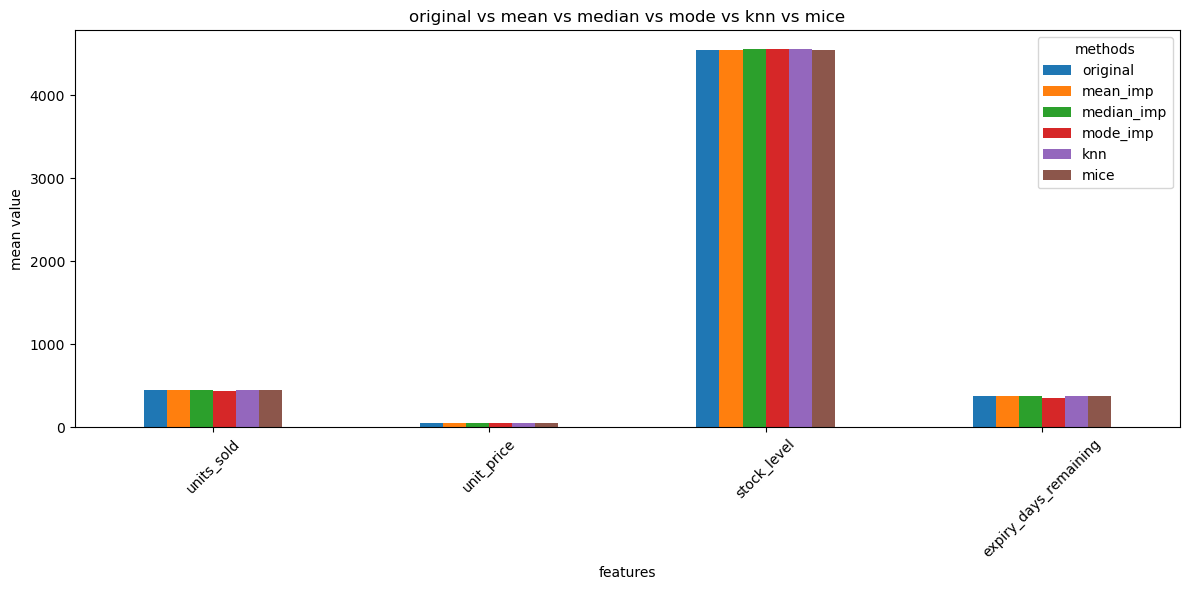

In [14]:
# data integrity check no.1 : compair mean value of the datasets with original
# (small change from original = better method)

mean_com = pd.DataFrame({
    "original": original[num_cols].mean(),
    "mean_imp": mean_data[num_cols].mean(),
    "median_imp": median_data[num_cols].mean(),
    "mode_imp": mode_data[num_cols].mean(),
    "knn": knn_data[num_cols].mean(),
    "mice": mice_data[num_cols].mean()
})

print(mean_com)

mean_com.plot(kind="bar", figsize=(12,6))
plt.title("original vs mean vs median vs mode vs knn vs mice")
plt.ylabel("mean value")
plt.xlabel("features")
plt.xticks(rotation=45)
plt.legend(title="methods")
plt.tight_layout()
plt.show()


                         original    mean_imp  median_imp    mode_imp  \
units_sold             364.674936  344.244325  344.838094  346.246356   
unit_price              27.107541   25.788589   25.789023   27.499586   
stock_level            364.363498  345.318189  345.603474  346.027270   
expiry_days_remaining  197.914651  188.195256  188.195826  197.664623   

                              knn        mice  
units_sold             346.593184  358.227829  
unit_price              26.068394   25.789491  
stock_level            347.995226  355.573479  
expiry_days_remaining  190.366569  188.195290  


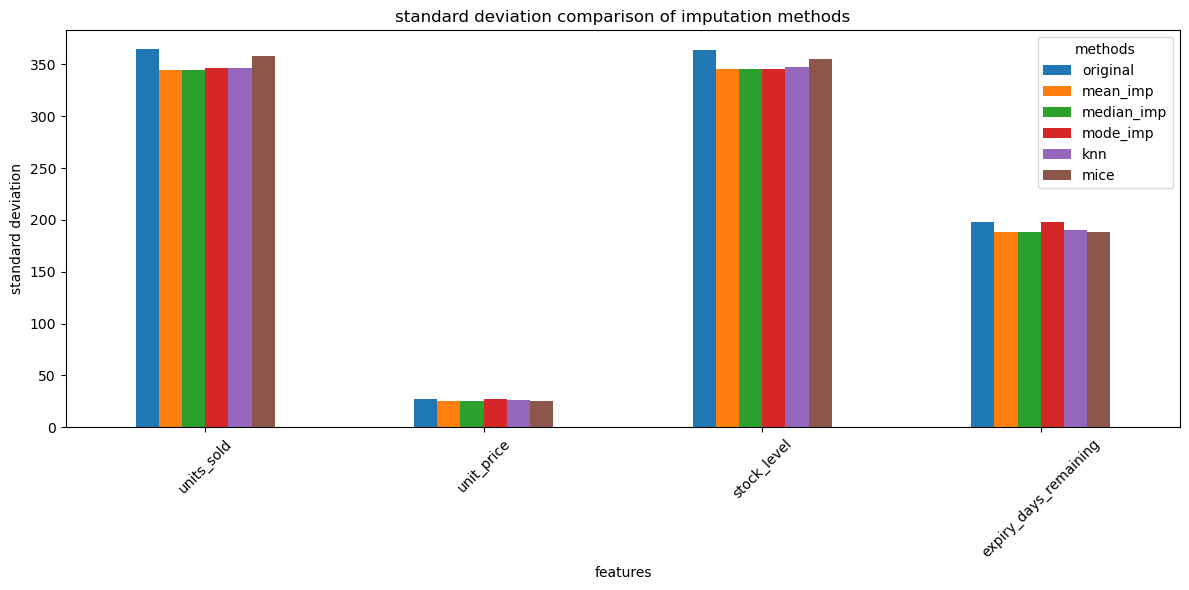

In [15]:
# STD is  checks whether the data spread is preserved
# method that keeps std close to original is the batter one

std_com = pd.DataFrame({
    "original": original[num_cols].std(),
    "mean_imp": mean_data[num_cols].std(),
    "median_imp": median_data[num_cols].std(),
    "mode_imp": mode_data[num_cols].std(),
    "knn": knn_data[num_cols].std(),
    "mice": mice_data[num_cols].std()
})

print(std_com)

std_com.plot(kind="bar", figsize=(12,6))
plt.title("standard deviation comparison of imputation methods")
plt.xlabel("features")
plt.ylabel("standard deviation")
plt.xticks(rotation=45)
plt.legend(title="methods")
plt.tight_layout()
plt.show()


In [16]:
# correlation checking relationship between col is preserved or not
print("original correlation")
print(original[num_cols].corr())

print("\nmean correlation")
print(mean_data[num_cols].corr())

print("\nmedian correlation")
print(median_data[num_cols].corr())

print("\nmode correlation")
print(mode_data[num_cols].corr())

print("\nknn correlation")
print(knn_data[num_cols].corr())

print("\nmice correlation")
print(mice_data[num_cols].corr())


original correlation
                       units_sold  unit_price  stock_level  \
units_sold               1.000000    0.003492    -0.934541   
unit_price               0.003492    1.000000    -0.004279   
stock_level             -0.934541   -0.004279     1.000000   
expiry_days_remaining   -0.002839    0.035213    -0.006297   

                       expiry_days_remaining  
units_sold                         -0.002839  
unit_price                          0.035213  
stock_level                        -0.006297  
expiry_days_remaining               1.000000  

mean correlation
                       units_sold  unit_price  stock_level  \
units_sold               1.000000    0.011174    -0.857428   
unit_price               0.011174    1.000000    -0.018561   
stock_level             -0.857428   -0.018561     1.000000   
expiry_days_remaining    0.006241    0.037983    -0.014854   

                       expiry_days_remaining  
units_sold                          0.006241  
unit_price

In [17]:
# smart compair, calculate correlation diffrence between method and original data
# then take abs remove nag and pos sign then average all diffrence lower is batter

mean_diff = (original[num_cols].corr() - mean_data[num_cols].corr()).abs().mean().mean()
median_diff = (original[num_cols].corr() - median_data[num_cols].corr()).abs().mean().mean()
mode_diff = (original[num_cols].corr() - mode_data[num_cols].corr()).abs().mean().mean()
knn_diff = (original[num_cols].corr() - knn_data[num_cols].corr()).abs().mean().mean()
mice_diff = (original[num_cols].corr() - mice_data[num_cols].corr()).abs().mean().mean()

print("mean difference:", mean_diff)
print("median difference:", median_diff)
print("mode difference:", mode_diff)
print("knn difference:", knn_diff)
print("mice difference:", mice_diff)


mean difference: 0.014935494842226688
median difference: 0.014989214077726057
mode difference: 0.017808020660229115
knn difference: 0.015227763465664344
mice difference: 0.006110462771281669


In [18]:
# now cross validation check, to validate imputation accuracy for every method
# we train a simple model to predict "units_sold" using other numeric col
# and compair cross val score r2 on data filled by each method, higher score = batter quality fill

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

target = "units_sold"
features = [c for c in num_cols if c != target]

cv_scores = {}

for name, data in [("mean", mean_data), ("median", median_data), ("mode", mode_data), ("knn", knn_data), ("mice", mice_data)]:
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    scores = cross_val_score(model, data[features], data[target], cv=5, scoring="r2")
    cv_scores[name] = scores.mean()

print("cross validation r2 score of every method:")
for k, v in cv_scores.items():
    print(k, ":", v)


cross validation r2 score of every method:
mean : 0.7139314810072867
median : 0.7105196773186409
mode : 0.6887960375999862
knn : 0.7208810376959243
mice : 0.8859507572929871


In [19]:
# lowest correlation difference and best cross validation  score mice = 0.88 so it is the best method for this dataset
# mode is worst here becuse it just repeat one single value again and again, it create problem for STD
# mean and median are simple, litle batter than mode but still reduce variance 
# knn and mice perform batter than all becuse they use relationship between columns to guess the missing value
